## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 반도체 사이클 통제변수 EDA
## ISTANS 반도체 생산·출하·재고·가동률 지수

이번 EDA의 목적은 **반도체 업황을 나타내는 통제변수를 만들기 전에 원자료가 어떤 특성을 가지고 있는지 최대한 확인하는 것**이다.

원자료에는 1999~2025년 반도체 산업의 다음 4개 지표가 있다.

- 생산지수 원지수
- 출하지수 원지수
- 재고지수 원지수
- 가동률지수 원지수

모두 ISTANS에서 내려받은 자료이며, 파일 메타정보상 생산·출하·재고·가동률 지표의 원출처는 국가데이터처(통계청) 「광업제조업동향조사」이라고 해서 다른 업종 파악하려면 이걸로 파악하면 될 듯

### 이번에 확인할 것

1. 파일 구조, 기간, 결측·중복 등 기본 검증
2. 4개 원지수의 분포와 장기 추세
3. 전년대비 증가율과 변화폭
4. 극단적인 연도와 이상치 후보
5. 생산·출하·재고·가동률 사이의 관계
6. 재고-출하 사이클
7. 재고부담, 출하-생산 괴리 등 보조지표
8. 시차 관계
9. 3년 이동평균과 표준화 지표
10. 2015~2023 분석기간 집중 확인
11. 여러 지표를 동시에 통제할 경우의 다중공선성
12. 단일 반도체 사이클 통제변수 후보로 PCA를 사용할 수 있는지 탐색

> 여기서는 통제변수를 바로 확정하지 않는다.  
> 먼저 각 지표가 어떤 정보를 담고 있고 서로 얼마나 중복되는지 확인한 뒤, 최종 회귀모형에서 어떤 변수를 사용할지 결정한다.

## 1. 데이터 불러오기 및 정리

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import font_manager
from IPython.display import display


file_path = RAW / "반도체" / "ISTANS_반도체_20260926214520.xlsx"
FIG_DIR = ROOT / "outputs" / "figures" / "semiconductor_cycle_eda"
TABLE_DIR = ROOT / "outputs" / "tables"
PROCESSED_DIR = ROOT / "data" / "processed"

for p in [FIG_DIR, TABLE_DIR, PROCESSED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# 한글 폰트
font_path = Path(r"C:\Windows\Fonts\malgun.ttf")

if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    font_name = font_manager.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams["font.family"] = font_name

plt.rcParams["axes.unicode_minus"] = False

print("파일 존재:", file_path.exists())
print("그래프 폰트:", plt.rcParams["font.family"])

raw = pd.read_excel(file_path, sheet_name="데이터")
meta = pd.read_excel(
    file_path,
    sheet_name="메타정보",
    header=None,
    names=["항목", "내용"]
)

display(raw)
display(meta.head(12))

파일 존재: True
그래프 폰트: ['Malgun Gothic']


<python-env> UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
<python-env> UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,IND 반도체(1),13999001 항목,Y1999 1999,Y2000 2000,Y2001 2001,Y2002 2002,Y2003 2003,Y2004 2004,Y2005 2005,Y2006 2006,...,Y2016 2016,Y2017 2017,Y2018 2018,Y2019 2019,Y2020 2020,Y2021 2021,Y2022 2022,Y2023 2023,Y2024 2024,Y2025 2025
0,IND 반도체,1 생산지수원지수 (14201.230331 2020=100),1.9,2.6,2.2,3.1,3.6,5.5,7.1,11.1,...,54.3,60.2,73.0,81.5,100.0,128.7,135.7,133.0,160.1,180.6
1,IND 반도체,3 출하지수원지수 (14201.230331 2020=100),2.1,2.8,2.4,3.4,4.0,5.8,7.6,11.4,...,54.8,59.1,70.1,78.4,100.0,122.7,126.3,137.5,157.5,178.4
2,IND 반도체,5 재고지수원지수 (14201.230331 2020=100),2.4,4.2,3.8,3.9,3.4,7.1,8.0,14.4,...,73.4,100.8,103.5,95.2,106.3,125.5,145.7,156.6,122.8,80.4
3,IND 반도체,7 가동률지수원지수 (14201.230331 2020=100),75.4,79.3,65.6,83.7,81.8,91.6,93.1,88.4,...,97.1,95.1,99.2,96.4,100.0,109.1,102.1,91.2,101.1,98.9


,항목,내용
0,○ 통계표ID,DT_IND_I3102
1,○ 통계표명,반도체
2,○ 조회기간,[년] 1999~2025
3,○ 출처,주석 참고
4,○ 자료다운일자,2026.09.26 21:01
5,○ 통계표URL,https://www.istans.or.kr/statHtml/statHtml.do?...
6,NaN,* KOSIS 개편 시 통계표 URL은 달라질 수 있음
7,○ 주석,NaN
8,통계표,출처 정보
9,NaN,"· 생산지수원지수~생산능력지수증가율전년동기비 : 국가데이터처 전산업생산지수, 광업제..."


### 파일 메타정보

현재 파일의 메타정보에는 다음이 기록되어 있다.

- 통계표 ID: `DT_IND_I3102`
- 통계표명: 반도체
- 조회기간: 1999~2025년
- 자료 다운로드일: 2026-09-26
- 생산·출하·재고·가동률 지표 원출처: 국가데이터처 「광업제조업동향조사」

ISTANS 통계표:
https://www.istans.or.kr/statHtml/statHtml.do?orgId=009&tblId=DT_IND_I3102&conn_path=I3

In [3]:
# wide 형태의 ISTANS 파일을 연도 × 지표 형태로 정리
item_col = raw.columns[1]
year_cols = [c for c in raw.columns if str(c).startswith("Y")]

def item_name(x):
    x = str(x)
    if "생산지수원지수" in x:
        return "생산지수"
    if "출하지수원지수" in x:
        return "출하지수"
    if "재고지수원지수" in x:
        return "재고지수"
    if "가동률지수원지수" in x:
        return "가동률지수"
    return None

rows = []

for _, row in raw.iterrows():
    indicator = item_name(row[item_col])

    if indicator is None:
        continue

    for c in year_cols:
        year = int(str(c).split()[1])

        rows.append({
            "연도": year,
            "지표": indicator,
            "값": row[c]
        })

long = pd.DataFrame(rows)

df = (
    long.pivot(index="연도", columns="지표", values="값")
    .reset_index()
)

order = ["연도", "생산지수", "출하지수", "재고지수", "가동률지수"]
df = df[order].sort_values("연도").reset_index(drop=True)

display(df)

지표,연도,생산지수,출하지수,재고지수,가동률지수
0,1999,1.9,2.1,2.4,75.4
1,2000,2.6,2.8,4.2,79.3
2,2001,2.2,2.4,3.8,65.6
3,2002,3.1,3.4,3.9,83.7
4,2003,3.6,4.0,3.4,81.8
5,2004,5.5,5.8,7.1,91.6
6,2005,7.1,7.6,8.0,93.1
7,2006,11.1,11.4,14.4,88.4
8,2007,13.3,13.9,17.8,83.9
9,2008,15.4,15.7,21.4,78.2


## 2. 원자료 구조 및 품질 확인

In [4]:
quality = pd.DataFrame({
    "항목": [
        "연도 수",
        "최초 연도",
        "최종 연도",
        "연도 중복",
        "연도 누락",
        "생산지수 결측",
        "출하지수 결측",
        "재고지수 결측",
        "가동률지수 결측",
        "무한대 값"
    ],
    "결과": [
        df["연도"].nunique(),
        df["연도"].min(),
        df["연도"].max(),
        df["연도"].duplicated().sum(),
        len(set(range(df["연도"].min(), df["연도"].max() + 1)) - set(df["연도"])),
        df["생산지수"].isna().sum(),
        df["출하지수"].isna().sum(),
        df["재고지수"].isna().sum(),
        df["가동률지수"].isna().sum(),
        np.isinf(df[["생산지수", "출하지수", "재고지수", "가동률지수"]]).sum().sum()
    ]
})

display(quality)

,항목,결과
0,연도 수,27
1,최초 연도,1999
2,최종 연도,2025
3,연도 중복,0
4,연도 누락,0
5,생산지수 결측,0
6,출하지수 결측,0
7,재고지수 결측,0
8,가동률지수 결측,0
9,무한대 값,0


### 기본 검증 결과

- 1999~2025년이 연속적으로 존재하는지 확인
- 연도 중복 여부 확인
- 4개 지표의 결측·무한대 여부 확인
- 이후 모든 EDA는 이 연도 패널을 기준으로 진행한다.

## 3. 2020=100 기준값 확인

In [5]:
base_2020 = df[df["연도"] == 2020].copy()
display(base_2020)

지표,연도,생산지수,출하지수,재고지수,가동률지수
21,2020,100.0,100.0,106.3,100.0


파일의 지표명에는 모두 `2020=100`이라고 표시되어 있다.

현재 자료에서는 2020년에:

- 생산지수 = 100
- 출하지수 = 100
- 가동률지수 = 100
- 재고지수 = 106.3

으로 나타난다.

재고지수만 2020년에 정확히 100이 아니기 때문에 처음 보면 이상하게 보일 수 있다.  
다만 통계청 「광업제조업동향조사」에서 재고는 생산·출하와 달리 **연말 재고액을 가중치 기준으로 사용하는 stock 성격의 지표**이고,
공식 연간 재고 통계에서도 연간 값이 12월 값과 동일하게 제시되는 사례가 확인된다.

따라서 이 값만으로 입력오류라고 판단하지 않는다.

외부 참고:
- 통계청 「광업제조업동향조사」 통계정보보고서  
  https://www.kostat.go.kr/boardDownload.es?bid=12030&list_no=428765&seq=1

이 차이 때문에 이후 분석에서는 **원지수 수준 자체보다 전년대비 증가율과 변화방향을 더 중요하게 본다.**

# Part A. 원지수 자체 EDA

## 4. 전체 원지수 기술통계

In [6]:
raw_cols = ["생산지수", "출하지수", "재고지수", "가동률지수"]

raw_desc = (
    df[raw_cols]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
)

raw_desc["왜도"] = df[raw_cols].skew()
raw_desc["첨도"] = df[raw_cols].kurt()

display(raw_desc.round(3))

,count,mean,std,min,5%,25%,50%,75%,95%,max,왜도,첨도
지표,,,,,,,,,,,,
생산지수,27.0,51.363,54.025,1.9,2.32,9.1,31.4,77.25,152.78,180.6,1.102,0.043
출하지수,27.0,50.452,52.907,2.1,2.52,9.5,30.2,74.25,151.50,178.4,1.121,0.114
재고지수,27.0,61.574,49.857,2.4,3.52,11.2,73.4,100.45,139.64,156.6,0.237,-1.308
가동률지수,27.0,89.137,9.675,65.6,76.24,82.8,88.4,96.75,101.80,109.1,-0.156,0.092


## 5. 전체 원지수 추이

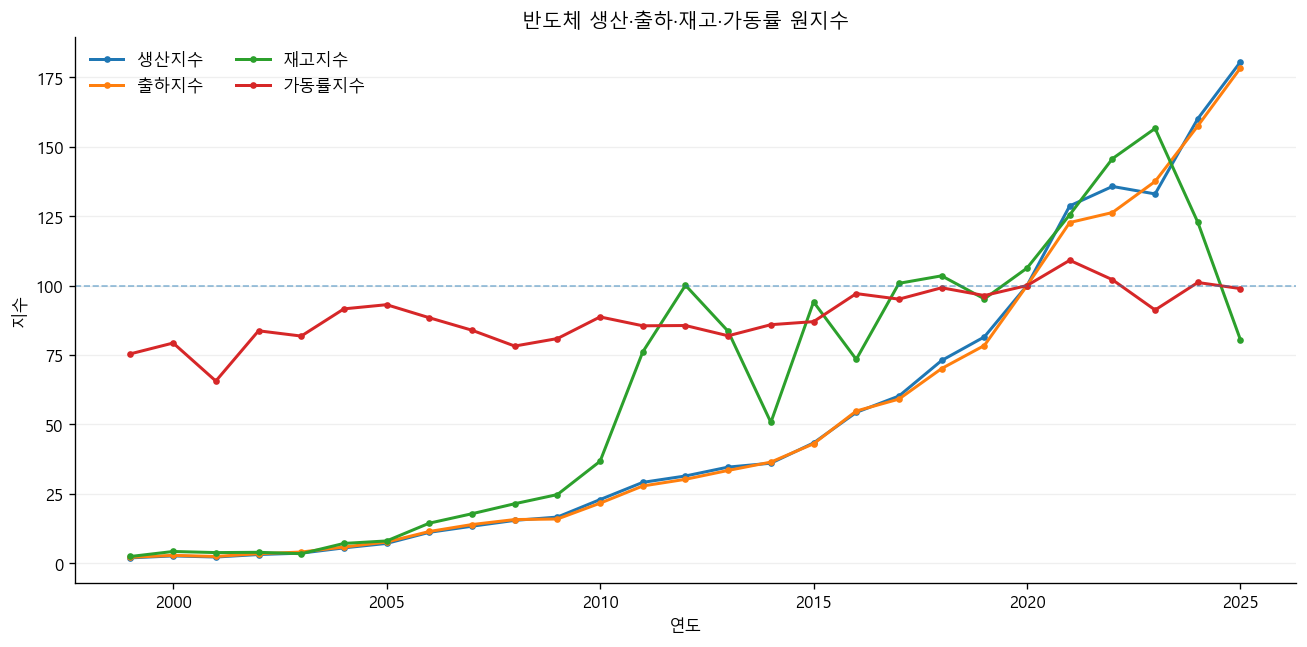

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)

for col in raw_cols:
    ax.plot(df["연도"], df[col], marker="o", markersize=3, linewidth=1.8, label=col)

ax.axhline(100, linewidth=1, linestyle="--", alpha=0.5)
ax.set_title("반도체 생산·출하·재고·가동률 원지수")
ax.set_xlabel("연도")
ax.set_ylabel("지수")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

생산과 출하는 장기적으로 강한 상승추세가 있고 서로 거의 같이 움직인다.

따라서 원지수의 높은 상관관계만 보고 두 변수가 같은 경기정보를 제공한다고 결론내리기보다는,
**장기추세를 제거한 전년대비 증가율에서도 같은 관계가 유지되는지** 확인해야 한다.

## 6. 각 지표를 따로 확인

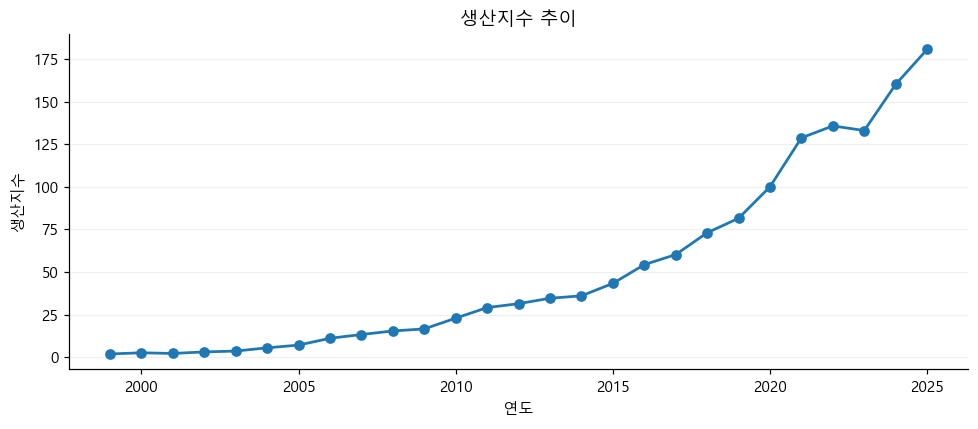

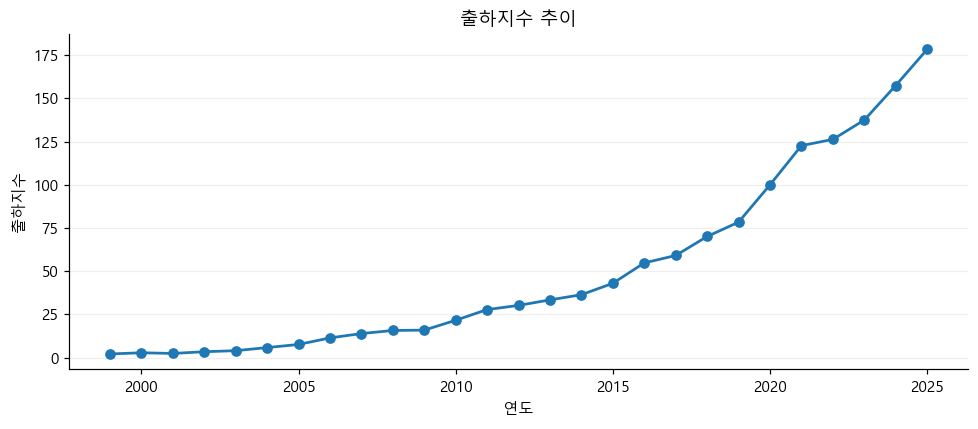

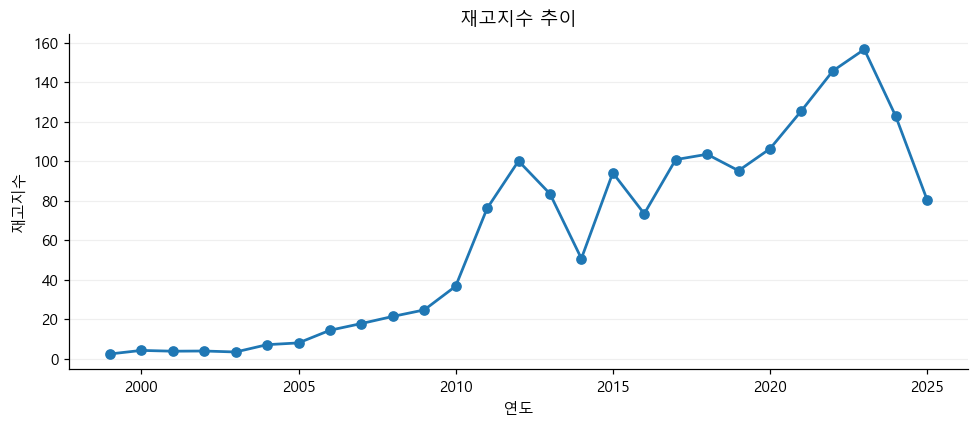

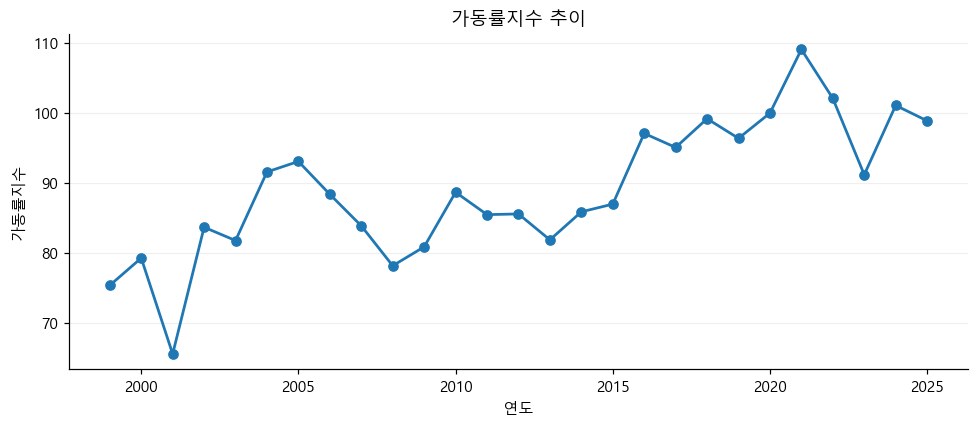

In [8]:
for col in raw_cols:
    fig, ax = plt.subplots(figsize=(9, 4), dpi=110)

    ax.plot(
        df["연도"],
        df[col],
        marker="o",
        linewidth=1.8
    )

    ax.set_title(f"{col} 추이")
    ax.set_xlabel("연도")
    ax.set_ylabel(col)
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

# Part B. 사이클을 보기 위한 전년대비 변화

## 7. 전년대비 증가율 및 보조지표 생성

In [9]:
for col in raw_cols:
    df[f"{col}_증가율"] = df[col].pct_change() * 100
    df[f"{col}_전년차"] = df[col].diff()

# 재고가 출하보다 얼마나 빠르게 쌓이는지 보는 보조값
df["재고압력"] = df["재고지수_증가율"] - df["출하지수_증가율"]

# 출하가 생산보다 얼마나 빠르거나 느린지
df["출하생산갭"] = df["출하지수_증가율"] - df["생산지수_증가율"]

display(df.tail(15).round(2))

지표,연도,생산지수,출하지수,재고지수,가동률지수,생산지수_증가율,생산지수_전년차,출하지수_증가율,출하지수_전년차,재고지수_증가율,재고지수_전년차,가동률지수_증가율,가동률지수_전년차,재고압력,출하생산갭
12,2011,29.1,27.8,76.1,85.5,27.07,6.2,28.70,6.2,107.36,39.4,-3.61,-3.2,78.65,1.63
13,2012,31.4,30.2,100.1,85.6,7.90,2.3,8.63,2.4,31.54,24.0,0.12,0.1,22.90,0.73
14,2013,34.6,33.4,83.5,81.9,10.19,3.2,10.60,3.2,-16.58,-16.6,-4.32,-3.7,-27.18,0.40
15,2014,36.0,36.4,50.7,85.9,4.05,1.4,8.98,3.0,-39.28,-32.8,4.88,4.0,-48.26,4.94
16,2015,43.3,43.0,94.1,87.0,20.28,7.3,18.13,6.6,85.60,43.4,1.28,1.1,67.47,-2.15
17,2016,54.3,54.8,73.4,97.1,25.40,11.0,27.44,11.8,-22.00,-20.7,11.61,10.1,-49.44,2.04
18,2017,60.2,59.1,100.8,95.1,10.87,5.9,7.85,4.3,37.33,27.4,-2.06,-2.0,29.48,-3.02
19,2018,73.0,70.1,103.5,99.2,21.26,12.8,18.61,11.0,2.68,2.7,4.31,4.1,-15.93,-2.65
20,2019,81.5,78.4,95.2,96.4,11.64,8.5,11.84,8.3,-8.02,-8.3,-2.82,-2.8,-19.86,0.20
21,2020,100.0,100.0,106.3,100.0,22.70,18.5,27.55,21.6,11.66,11.1,3.73,3.6,-15.89,4.85


### 파생변수 해석

`재고압력 = 재고 증가율 - 출하 증가율`

- 값이 커질수록 출하보다 재고가 상대적으로 빠르게 증가
- 값이 작거나 음수이면 출하 대비 재고부담이 줄어드는 방향

`출하생산갭 = 출하 증가율 - 생산 증가율`

- 양수: 출하가 생산보다 빠르게 증가
- 음수: 생산 증가가 출하 증가보다 빠름

두 값 모두 **공식 통계지표가 아니라 EDA를 위한 보조지표**이며,
그 자체를 최종 통제변수로 바로 사용하지 않는다.

## 8. 증가율 기술통계

In [10]:
growth_cols = [
    "생산지수_증가율",
    "출하지수_증가율",
    "재고지수_증가율",
    "가동률지수_증가율",
    "재고압력",
    "출하생산갭"
]

growth_desc = (
    df[growth_cols]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
)

growth_desc["왜도"] = df[growth_cols].skew()
growth_desc["첨도"] = df[growth_cols].kurt()

display(growth_desc.round(3))

,count,mean,std,min,5%,25%,50%,75%,95%,max,왜도,첨도
지표,,,,,,,,,,,,
생산지수_증가율,26.0,20.183,16.143,-15.385,-0.481,10.360,20.049,28.294,49.811,56.338,0.338,0.530
출하지수_증가율,26.0,19.502,14.654,-14.286,1.689,9.386,17.889,28.416,44.167,50.000,0.138,0.167
재고지수_증가율,26.0,20.786,41.314,-39.281,-31.395,-9.148,14.048,35.882,101.918,108.824,0.799,-0.088
가동률지수_증가율,26.0,1.416,8.912,-17.276,-9.705,-4.144,0.699,5.100,11.888,27.591,0.720,1.983
재고압력,26.0,1.284,35.905,-49.440,-48.147,-25.349,0.147,20.715,66.558,78.653,0.519,-0.341
출하생산갭,26.0,-0.681,4.189,-7.778,-6.473,-2.974,0.301,1.602,4.915,10.857,0.525,0.941


## 9. 생산·출하·재고 증가율 추이

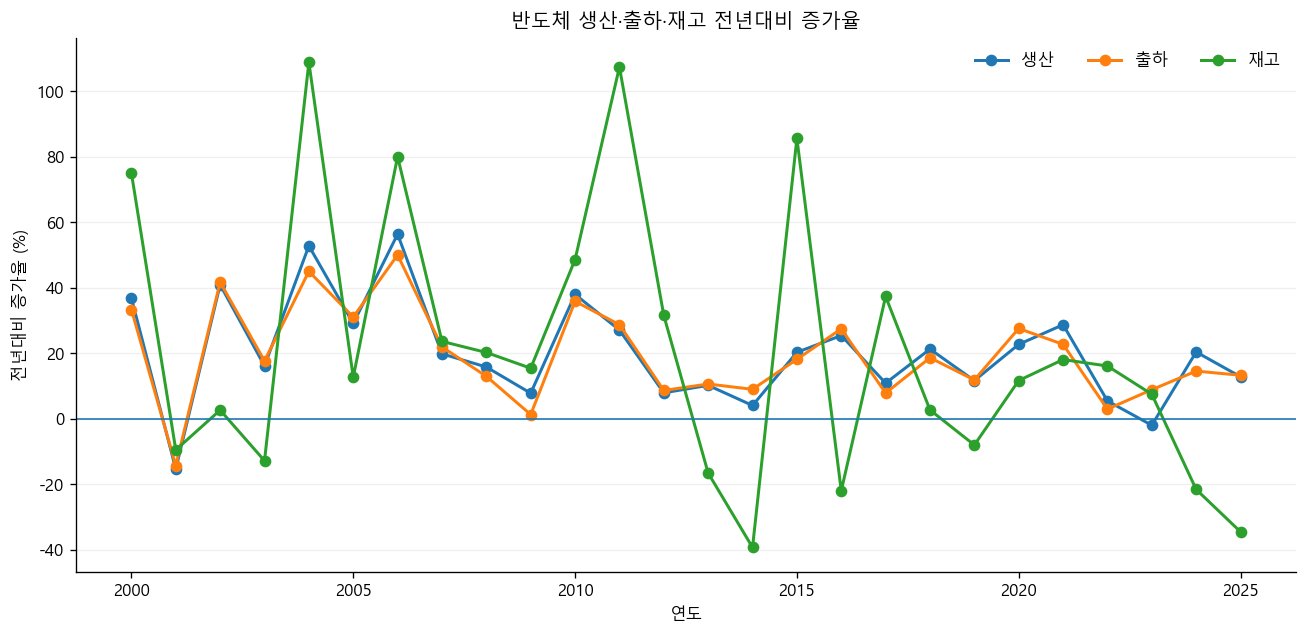

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.4), dpi=120)

for col in ["생산지수_증가율", "출하지수_증가율", "재고지수_증가율"]:
    ax.plot(
        df["연도"],
        df[col],
        marker="o",
        linewidth=1.8,
        label=col.replace("지수_증가율", "")
    )

ax.axhline(0, linewidth=1)
ax.set_title("반도체 생산·출하·재고 전년대비 증가율")
ax.set_xlabel("연도")
ax.set_ylabel("전년대비 증가율 (%)")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 10. 가동률 변화

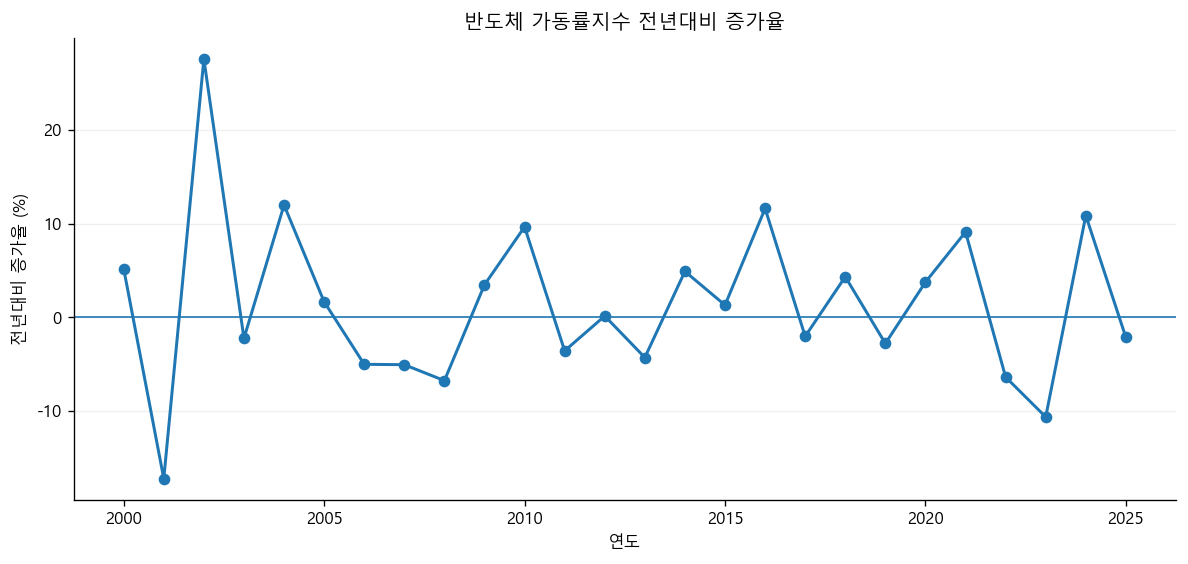

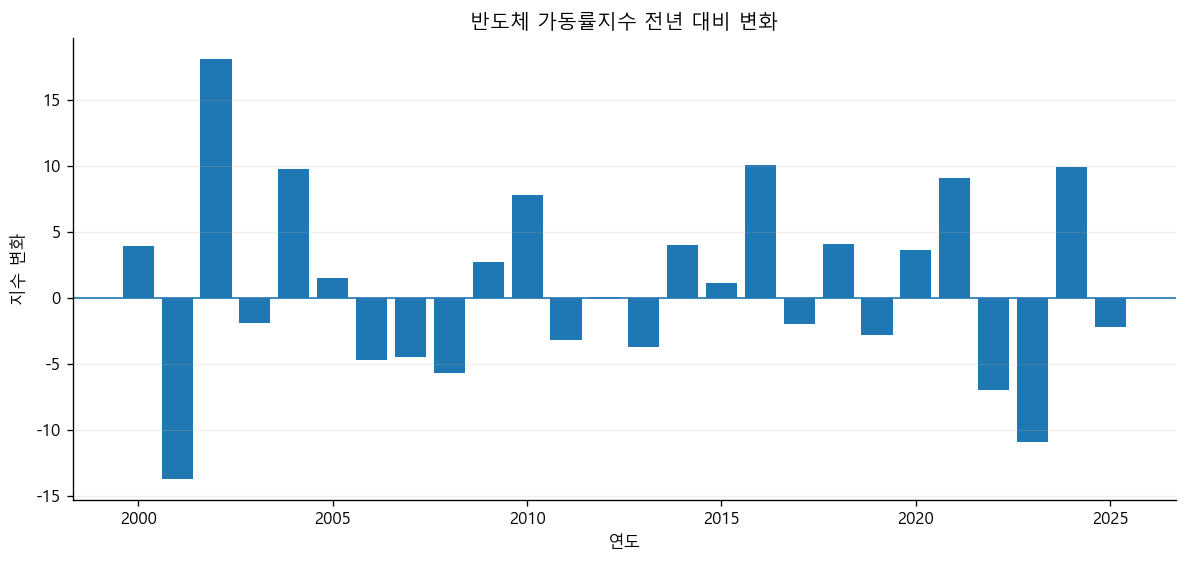

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=120)

ax.plot(
    df["연도"],
    df["가동률지수_증가율"],
    marker="o",
    linewidth=1.8,
    label="가동률 증가율"
)

ax.axhline(0, linewidth=1)
ax.set_title("반도체 가동률지수 전년대비 증가율")
ax.set_xlabel("연도")
ax.set_ylabel("전년대비 증가율 (%)")
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.8), dpi=120)

ax.bar(df["연도"], df["가동률지수_전년차"])
ax.axhline(0, linewidth=1)

ax.set_title("반도체 가동률지수 전년 대비 변화")
ax.set_xlabel("연도")
ax.set_ylabel("지수 변화")
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Part C. 극단값·이상연도 확인

## 11. IQR 기준 이상치 후보

In [13]:
outlier_rows = []

for col in growth_cols:
    s = df[["연도", col]].dropna().copy()

    q1 = s[col].quantile(0.25)
    q3 = s[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    temp = s[(s[col] < lower) | (s[col] > upper)].copy()
    temp["변수"] = col
    temp["하한"] = lower
    temp["상한"] = upper
    temp = temp.rename(columns={col: "값"})

    outlier_rows.append(temp[["연도", "변수", "값", "하한", "상한"]])

iqr_outliers = pd.concat(outlier_rows, ignore_index=True)

display(iqr_outliers.round(2))

지표,연도,변수,값,하한,상한
0,2006,생산지수_증가율,56.34,-16.54,55.19
1,2004,재고지수_증가율,108.82,-76.69,103.43
2,2011,재고지수_증가율,107.36,-76.69,103.43
3,2002,가동률지수_증가율,27.59,-18.01,18.97
4,2023,출하생산갭,10.86,-9.84,8.47


IQR 기준으로 플래그된 연도는 **삭제대상**이 아니라 추가 확인대상이다.

반도체 산업은 경기순환과 기술·수요 충격이 큰 산업이라,
큰 변화가 실제 업황을 반영한 정상 관측치일 가능성이 높다.

## 12. 표준화 z-score로 큰 변화 확인

In [14]:
z_cols = [
    "생산지수_증가율",
    "출하지수_증가율",
    "재고지수_증가율",
    "가동률지수_증가율",
    "재고압력"
]

z = df[["연도"] + z_cols].copy()

for col in z_cols:
    z[f"{col}_z"] = (
        (z[col] - z[col].mean())
        / z[col].std(ddof=0)
    )

z_score_cols = [c for c in z.columns if c.endswith("_z")]

z["절대z최대"] = z[z_score_cols].abs().max(axis=1)

display(
    z.sort_values("절대z최대", ascending=False)
    .head(12)
    .round(2)
)

지표,연도,생산지수_증가율,출하지수_증가율,재고지수_증가율,가동률지수_증가율,재고압력,생산지수_증가율_z,출하지수_증가율_z,재고지수_증가율_z,가동률지수_증가율_z,재고압력_z,절대z최대
3,2002,40.91,41.67,2.63,27.59,-39.04,1.31,1.54,-0.45,3.00,-1.15,3.00
2,2001,-15.38,-14.29,-9.52,-17.28,4.76,-2.25,-2.35,-0.75,-2.14,0.10,2.35
7,2006,56.34,50.00,80.00,-5.05,30.00,2.28,2.12,1.46,-0.74,0.82,2.28
12,2011,27.07,28.70,107.36,-3.61,78.65,0.44,0.64,2.14,-0.57,2.20,2.20
5,2004,52.78,45.00,108.82,11.98,63.82,2.06,1.77,2.17,1.21,1.78,2.17
16,2015,20.28,18.13,85.60,1.28,67.47,0.01,-0.10,1.60,-0.02,1.88,1.88
15,2014,4.05,8.98,-39.28,4.88,-48.26,-1.02,-0.73,-1.48,0.40,-1.41,1.48
17,2016,25.40,27.44,-22.00,11.61,-49.44,0.33,0.55,-1.06,1.17,-1.44,1.44
24,2023,-1.99,8.87,7.48,-10.68,-1.39,-1.40,-0.74,-0.33,-1.38,-0.08,1.40
26,2025,12.80,13.27,-34.53,-2.18,-47.80,-0.47,-0.43,-1.37,-0.41,-1.39,1.39


## 13. 변수별 상위·하위 연도

In [15]:
for col in [
    "생산지수_증가율",
    "출하지수_증가율",
    "재고지수_증가율",
    "가동률지수_증가율",
    "재고압력"
]:
    print(f"\n[{col} 상위 5개 연도]")
    display(df.nlargest(5, col)[["연도", col]].round(2))

    print(f"[{col} 하위 5개 연도]")
    display(df.nsmallest(5, col)[["연도", col]].round(2))


[생산지수_증가율 상위 5개 연도]


지표,연도,생산지수_증가율
7,2006,56.34
5,2004,52.78
3,2002,40.91
11,2010,37.95
1,2000,36.84


[생산지수_증가율 하위 5개 연도]


지표,연도,생산지수_증가율
2,2001,-15.38
24,2023,-1.99
15,2014,4.05
23,2022,5.44
10,2009,7.79



[출하지수_증가율 상위 5개 연도]


...

지표,연도,가동률지수_증가율
2,2001,-17.28
24,2023,-10.68
9,2008,-6.79
23,2022,-6.42
8,2007,-5.09



[재고압력 상위 5개 연도]


지표,연도,재고압력
12,2011,78.65
16,2015,67.47
5,2004,63.82
1,2000,41.67
7,2006,30.00


[재고압력 하위 5개 연도]


지표,연도,재고압력
17,2016,-49.44
15,2014,-48.26
26,2025,-47.80
3,2002,-39.04
25,2024,-36.13


# Part D. 변수 간 관계

## 14. 원지수 상관관계

지표,생산지수,출하지수,재고지수,가동률지수
지표,,,,
생산지수,1.000,0.999,0.825,0.759
출하지수,0.999,1.000,0.822,0.750
재고지수,0.825,0.822,1.000,0.696
가동률지수,0.759,0.750,0.696,1.000


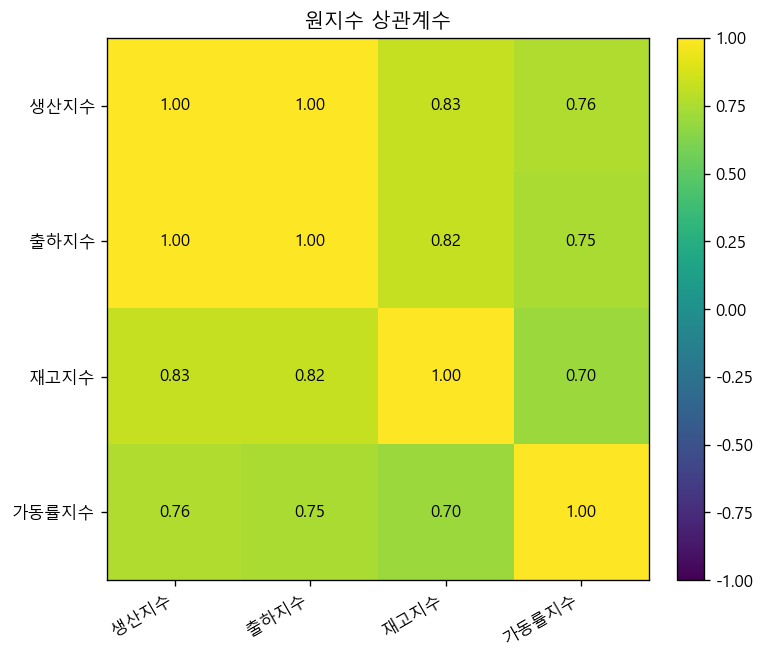

In [16]:
corr_raw = df[raw_cols].corr()

display(corr_raw.round(3))

fig, ax = plt.subplots(figsize=(6.8, 5.6), dpi=120)
im = ax.imshow(corr_raw, vmin=-1, vmax=1)

ax.set_xticks(range(len(raw_cols)))
ax.set_xticklabels(raw_cols, rotation=30, ha="right")
ax.set_yticks(range(len(raw_cols)))
ax.set_yticklabels(raw_cols)

for i in range(len(raw_cols)):
    for j in range(len(raw_cols)):
        ax.text(j, i, f"{corr_raw.iloc[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("원지수 상관계수")

plt.tight_layout()
plt.show()

원지수끼리의 상관계수는 장기적인 상승추세의 영향을 많이 받는다.

특히 생산과 출하는 거의 동일한 방향으로 장기 상승하기 때문에
원지수 상관계수가 매우 높게 나타날 수 있다.

통제변수 후보를 판단할 때는 아래의 **증가율 상관관계**를 더 중요하게 본다.

## 15. 증가율 상관관계

지표,생산지수_증가율,출하지수_증가율,재고지수_증가율,가동률지수_증가율
지표,,,,
생산지수_증가율,1.000,0.968,0.577,0.597
출하지수_증가율,0.968,1.000,0.522,0.579
재고지수_증가율,0.577,0.522,1.000,0.027
가동률지수_증가율,0.597,0.579,0.027,1.000


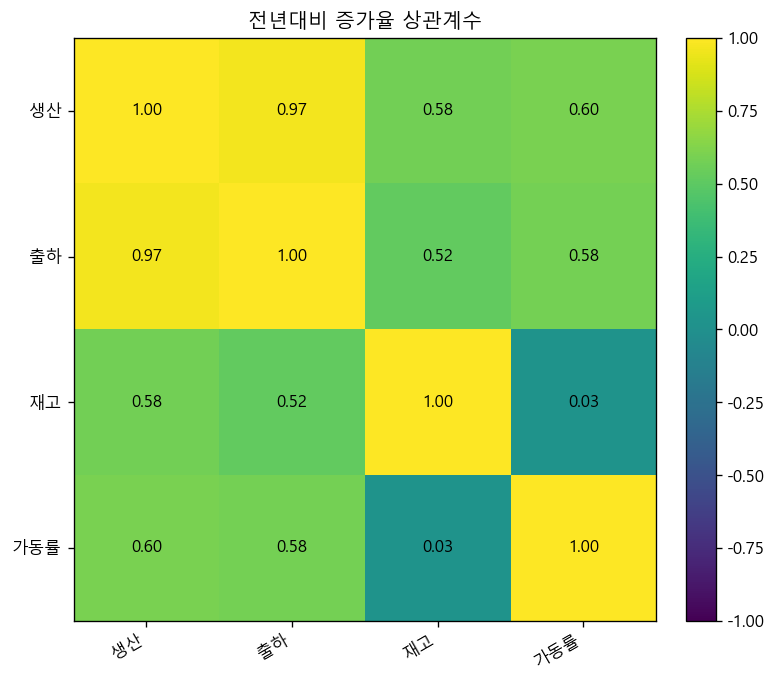

In [17]:
core_growth = [
    "생산지수_증가율",
    "출하지수_증가율",
    "재고지수_증가율",
    "가동률지수_증가율"
]

corr_growth = df[core_growth].corr()

display(corr_growth.round(3))

fig, ax = plt.subplots(figsize=(7, 5.8), dpi=120)
im = ax.imshow(corr_growth, vmin=-1, vmax=1)

ax.set_xticks(range(len(core_growth)))
ax.set_xticklabels(
    [c.replace("지수_증가율", "") for c in core_growth],
    rotation=30,
    ha="right"
)
ax.set_yticks(range(len(core_growth)))
ax.set_yticklabels(
    [c.replace("지수_증가율", "") for c in core_growth]
)

for i in range(len(core_growth)):
    for j in range(len(core_growth)):
        ax.text(j, i, f"{corr_growth.iloc[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("전년대비 증가율 상관계수")

plt.tight_layout()
plt.show()

현재 자료에서는 생산 증가율과 출하 증가율이 매우 높은 상관을 보인다.

따라서 두 변수를 동시에 통제변수로 넣으면
반도체 업황의 거의 같은 측면을 중복해서 넣을 가능성이 있다.

반면 재고와 가동률은 생산·출하와 완전히 같은 움직임은 아니어서
별도의 업황정보를 추가할 가능성이 있다.

## 16. 주요 변수 산점도

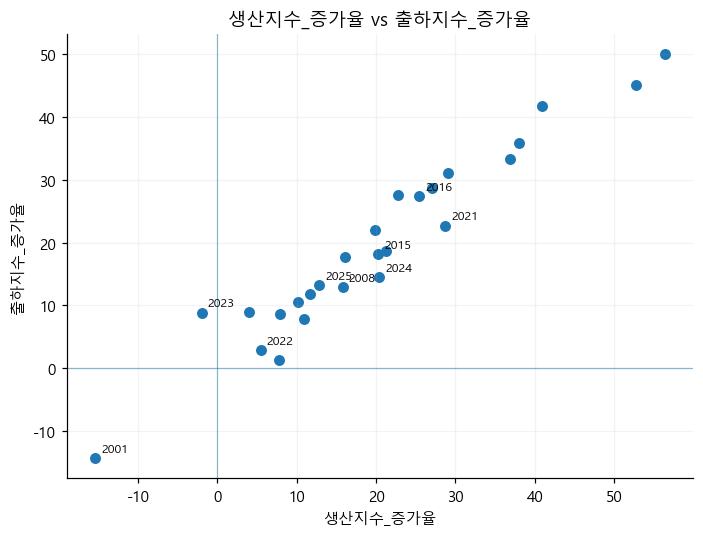

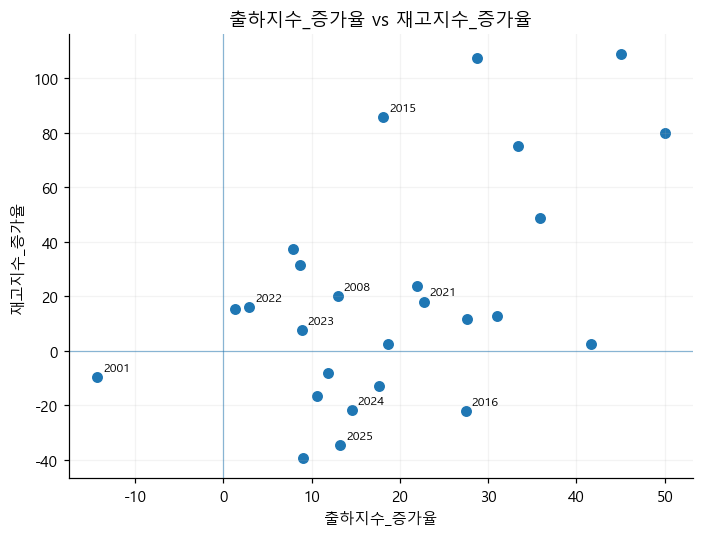

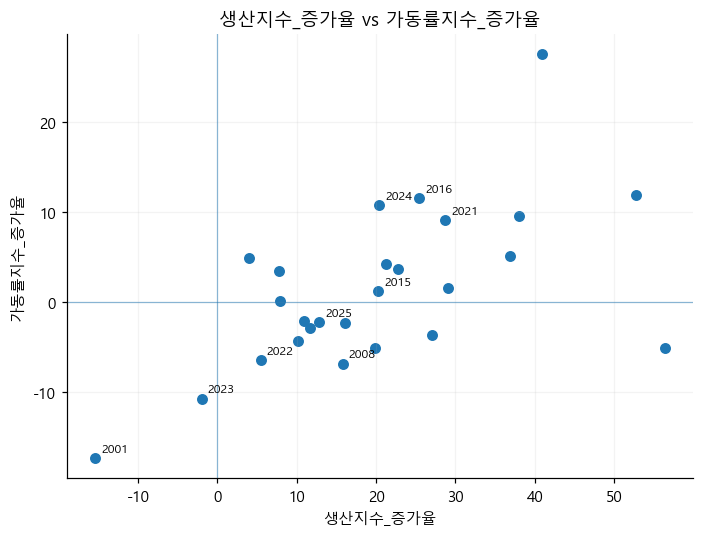

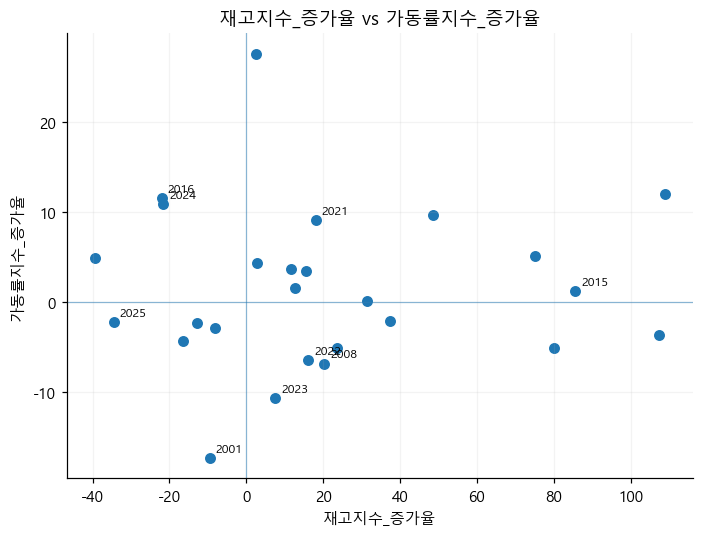

In [18]:
pairs = [
    ("생산지수_증가율", "출하지수_증가율"),
    ("출하지수_증가율", "재고지수_증가율"),
    ("생산지수_증가율", "가동률지수_증가율"),
    ("재고지수_증가율", "가동률지수_증가율")
]

for xcol, ycol in pairs:
    temp = df[["연도", xcol, ycol]].dropna()

    fig, ax = plt.subplots(figsize=(6.5, 5), dpi=110)

    ax.scatter(temp[xcol], temp[ycol], s=38)

    for _, r in temp.iterrows():
        if r["연도"] in [2001, 2008, 2015, 2016, 2021, 2022, 2023, 2024, 2025]:
            ax.annotate(
                int(r["연도"]),
                (r[xcol], r[ycol]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8
            )

    ax.axhline(0, linewidth=0.8, alpha=0.5)
    ax.axvline(0, linewidth=0.8, alpha=0.5)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{xcol} vs {ycol}")
    ax.grid(alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

# Part E. 재고-출하 사이클

한국은행은 반도체 업황을 설명할 때 **재고 변화와 출하 변화를 함께 보는 재고-출하 사이클**을 사용한다.

일반적으로 수요가 약해질 때 생산조정이 늦으면 재고가 쌓일 수 있고,
회복기에는 출하가 개선되면서 재고부담이 줄어드는 형태가 나타날 수 있다.

외부 참고:
- 한국은행, semiconductor inventory-shipment cycle  
  https://file-cdn.bok.or.kr/eng/7c12c850866b9e161d69e4e4e81cd2ae/1/202302100326276540.pdf

현재 자료는 **연간 자료**이므로 한국은행의 분기 단위 분석보다 사이클 전환시점을 세밀하게 잡지는 못한다.
따라서 아래 그래프는 구조를 확인하는 보조 EDA로 사용한다.

## 17. 전체 재고-출하 증가율 산점도

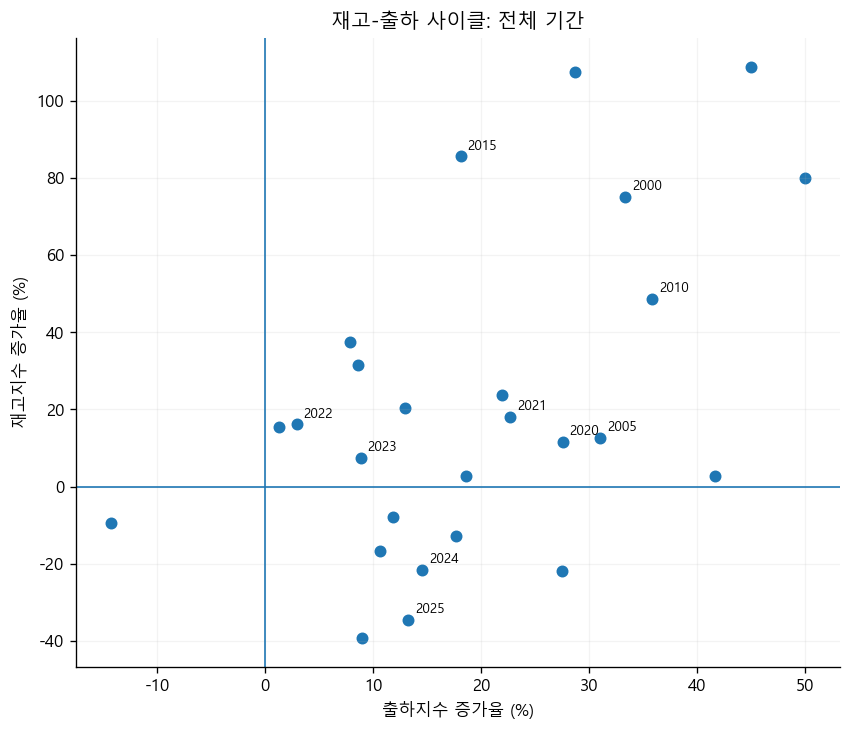

In [19]:
cycle = df[
    ["연도", "출하지수_증가율", "재고지수_증가율"]
].dropna().copy()

fig, ax = plt.subplots(figsize=(7.2, 6.2), dpi=120)

ax.scatter(
    cycle["출하지수_증가율"],
    cycle["재고지수_증가율"],
    s=38
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

for _, r in cycle.iterrows():
    if r["연도"] % 5 == 0 or r["연도"] >= 2020:
        ax.annotate(
            int(r["연도"]),
            (r["출하지수_증가율"], r["재고지수_증가율"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

ax.set_xlabel("출하지수 증가율 (%)")
ax.set_ylabel("재고지수 증가율 (%)")
ax.set_title("재고-출하 사이클: 전체 기간")
ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 18. 2015~2025 재고-출하 사이클 이동경로

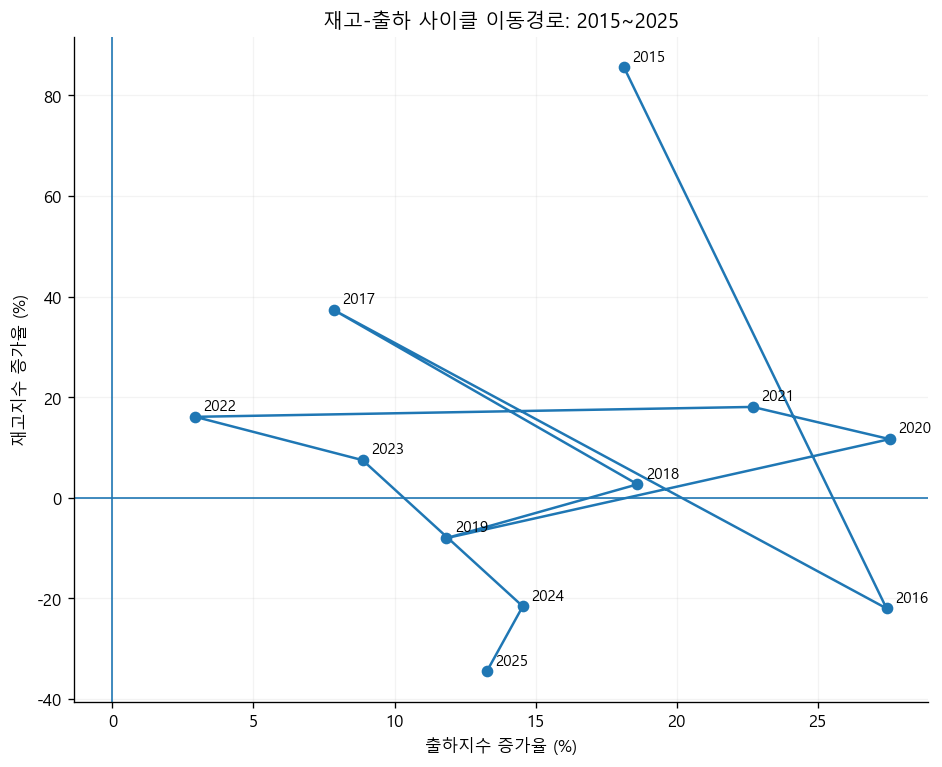

In [20]:
cycle_focus = cycle[cycle["연도"].between(2015, 2025)].copy()

fig, ax = plt.subplots(figsize=(8, 6.5), dpi=120)

ax.plot(
    cycle_focus["출하지수_증가율"],
    cycle_focus["재고지수_증가율"],
    marker="o",
    linewidth=1.5
)

for _, r in cycle_focus.iterrows():
    ax.annotate(
        int(r["연도"]),
        (r["출하지수_증가율"], r["재고지수_증가율"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9
    )

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel("출하지수 증가율 (%)")
ax.set_ylabel("재고지수 증가율 (%)")
ax.set_title("재고-출하 사이클 이동경로: 2015~2025")
ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 19. 재고압력

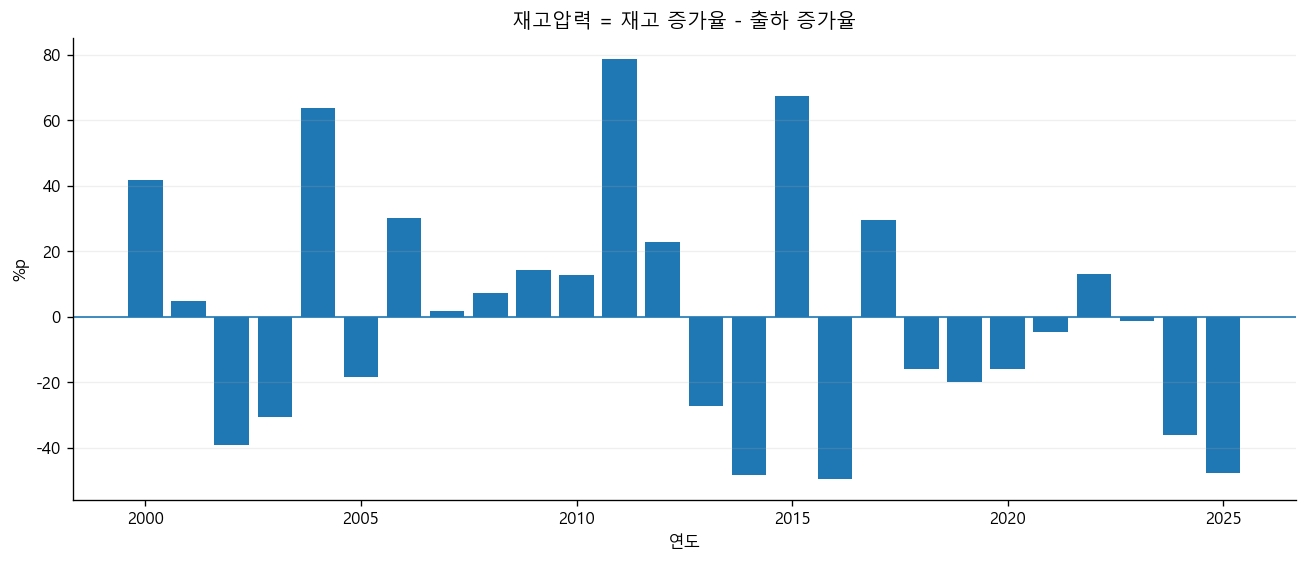

In [21]:
fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)

ax.bar(df["연도"], df["재고압력"])
ax.axhline(0, linewidth=1)

ax.set_title("재고압력 = 재고 증가율 - 출하 증가율")
ax.set_xlabel("연도")
ax.set_ylabel("%p")
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Part F. 시차·지속성 확인

## 20. 전년 증가율의 1년 자기상관

In [22]:
autocorr_rows = []

for col in core_growth:
    temp = df[col].dropna()

    autocorr_rows.append({
        "변수": col,
        "lag1_자기상관": temp.autocorr(lag=1)
    })

autocorr_table = pd.DataFrame(autocorr_rows)

display(autocorr_table.round(3))

,변수,lag1_자기상관
0,생산지수_증가율,-0.104
1,출하지수_증가율,-0.083
2,재고지수_증가율,-0.081
3,가동률지수_증가율,-0.411


## 21. 출하와 재고의 lead-lag 상관

,lag,상관계수
0,-2,0.007
1,-1,-0.104
2,0,0.522
3,1,0.177
4,2,0.305


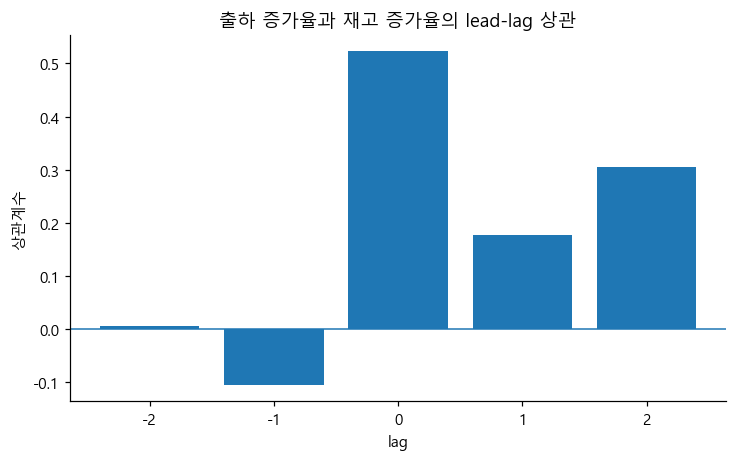

In [23]:
leadlag = []

base = df.set_index("연도")[
    ["출하지수_증가율", "재고지수_증가율"]
].dropna()

for lag in range(-2, 3):
    corr = base["출하지수_증가율"].corr(
        base["재고지수_증가율"].shift(-lag)
    )

    leadlag.append({
        "lag": lag,
        "상관계수": corr
    })

leadlag = pd.DataFrame(leadlag)

display(leadlag.round(3))

fig, ax = plt.subplots(figsize=(6.8, 4.3), dpi=110)

ax.bar(leadlag["lag"], leadlag["상관계수"])
ax.axhline(0, linewidth=1)

ax.set_title("출하 증가율과 재고 증가율의 lead-lag 상관")
ax.set_xlabel("lag")
ax.set_ylabel("상관계수")
ax.set_xticks(leadlag["lag"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

연간 자료가 26개 변화율 관측치뿐이기 때문에 시차상관은 표본이 작다.

따라서 특정 lag가 높다고 해서 인과관계나 선행성을 확정하지 않고,
**연간 자료에서 뚜렷한 시차패턴이 존재하는지 탐색하는 수준**으로만 사용한다.

# Part G. 이동평균과 표준화

## 22. 3년 이동평균

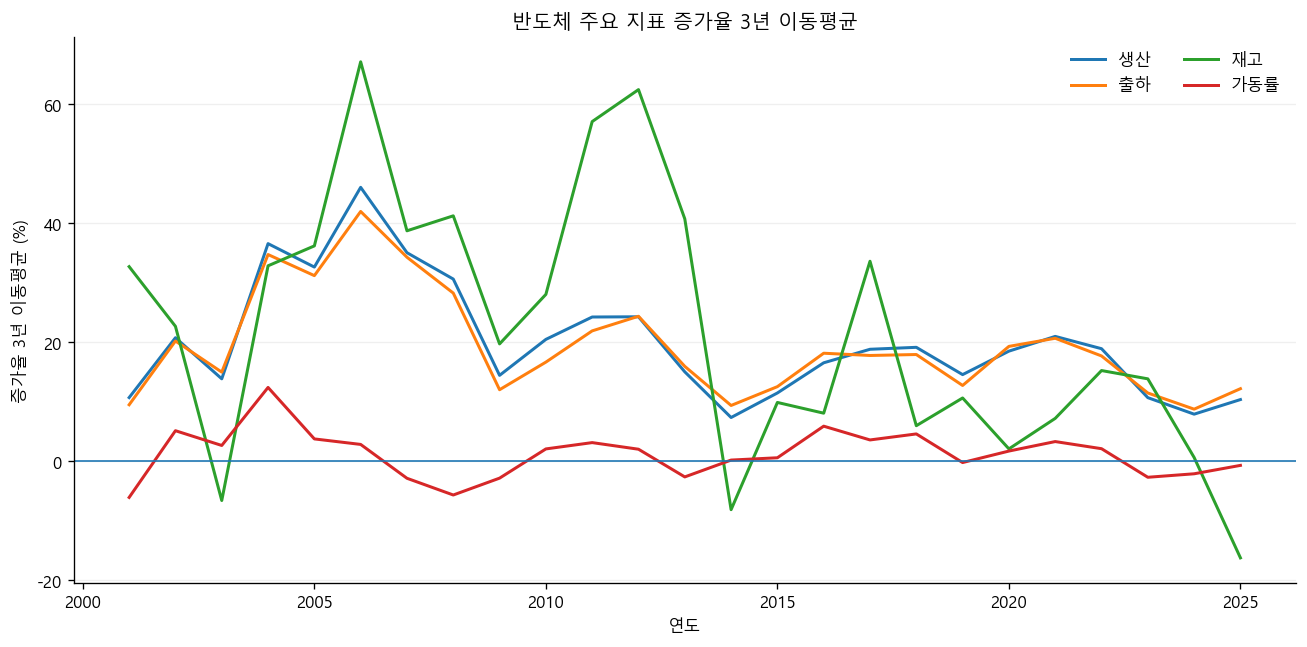

In [24]:
for col in core_growth:
    df[f"{col}_MA3"] = df[col].rolling(3, min_periods=2).mean()

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)

for col in core_growth:
    ax.plot(
        df["연도"],
        df[f"{col}_MA3"],
        linewidth=1.8,
        label=col.replace("지수_증가율", "")
    )

ax.axhline(0, linewidth=1)
ax.set_title("반도체 주요 지표 증가율 3년 이동평균")
ax.set_xlabel("연도")
ax.set_ylabel("증가율 3년 이동평균 (%)")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 23. 표준화 z-score heatmap

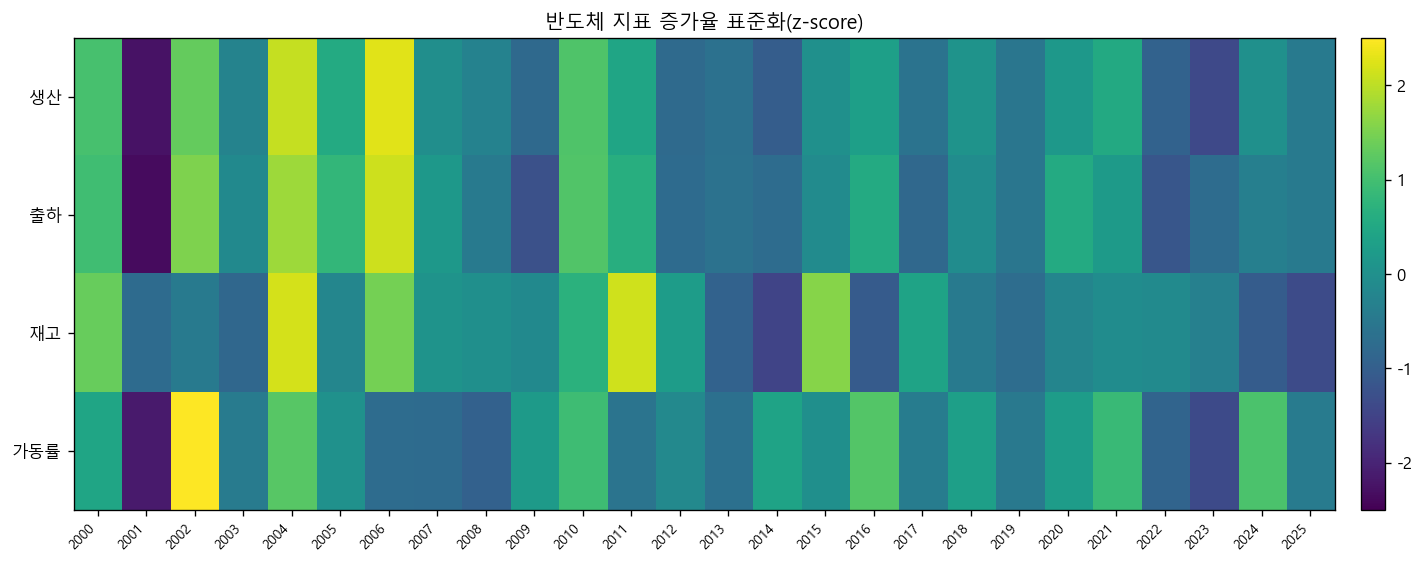

In [25]:
heat = df[["연도"] + core_growth].dropna().copy()

for col in core_growth:
    heat[col] = (
        (heat[col] - heat[col].mean())
        / heat[col].std(ddof=0)
    )

matrix = heat[core_growth].T.values

fig, ax = plt.subplots(figsize=(12, 4.8), dpi=120)

im = ax.imshow(matrix, aspect="auto", vmin=-2.5, vmax=2.5)

ax.set_yticks(range(len(core_growth)))
ax.set_yticklabels(
    [c.replace("지수_증가율", "") for c in core_growth]
)

ax.set_xticks(range(len(heat)))
ax.set_xticklabels(
    heat["연도"].astype(int),
    rotation=45,
    ha="right",
    fontsize=8
)

plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
ax.set_title("반도체 지표 증가율 표준화(z-score)")

plt.tight_layout()
plt.show()

# Part H. 프로젝트 분석기간 2015~2023

## 24. 분석기간 상세표

In [26]:
analysis_period = df[
    df["연도"].between(2015, 2023)
][
    [
        "연도",
        "생산지수", "출하지수", "재고지수", "가동률지수",
        "생산지수_증가율",
        "출하지수_증가율",
        "재고지수_증가율",
        "가동률지수_증가율",
        "가동률지수_전년차",
        "재고압력",
        "출하생산갭"
    ]
].copy()

display(analysis_period.round(2))

지표,연도,생산지수,출하지수,재고지수,가동률지수,생산지수_증가율,출하지수_증가율,재고지수_증가율,가동률지수_증가율,가동률지수_전년차,재고압력,출하생산갭
16,2015,43.3,43.0,94.1,87.0,20.28,18.13,85.60,1.28,1.1,67.47,-2.15
17,2016,54.3,54.8,73.4,97.1,25.40,27.44,-22.00,11.61,10.1,-49.44,2.04
18,2017,60.2,59.1,100.8,95.1,10.87,7.85,37.33,-2.06,-2.0,29.48,-3.02
19,2018,73.0,70.1,103.5,99.2,21.26,18.61,2.68,4.31,4.1,-15.93,-2.65
20,2019,81.5,78.4,95.2,96.4,11.64,11.84,-8.02,-2.82,-2.8,-19.86,0.20
21,2020,100.0,100.0,106.3,100.0,22.70,27.55,11.66,3.73,3.6,-15.89,4.85
22,2021,128.7,122.7,125.5,109.1,28.70,22.70,18.06,9.10,9.1,-4.64,-6.00
23,2022,135.7,126.3,145.7,102.1,5.44,2.93,16.10,-6.42,-7.0,13.16,-2.51
24,2023,133.0,137.5,156.6,91.2,-1.99,8.87,7.48,-10.68,-10.9,-1.39,10.86


## 25. 분석기간 증가율 비교

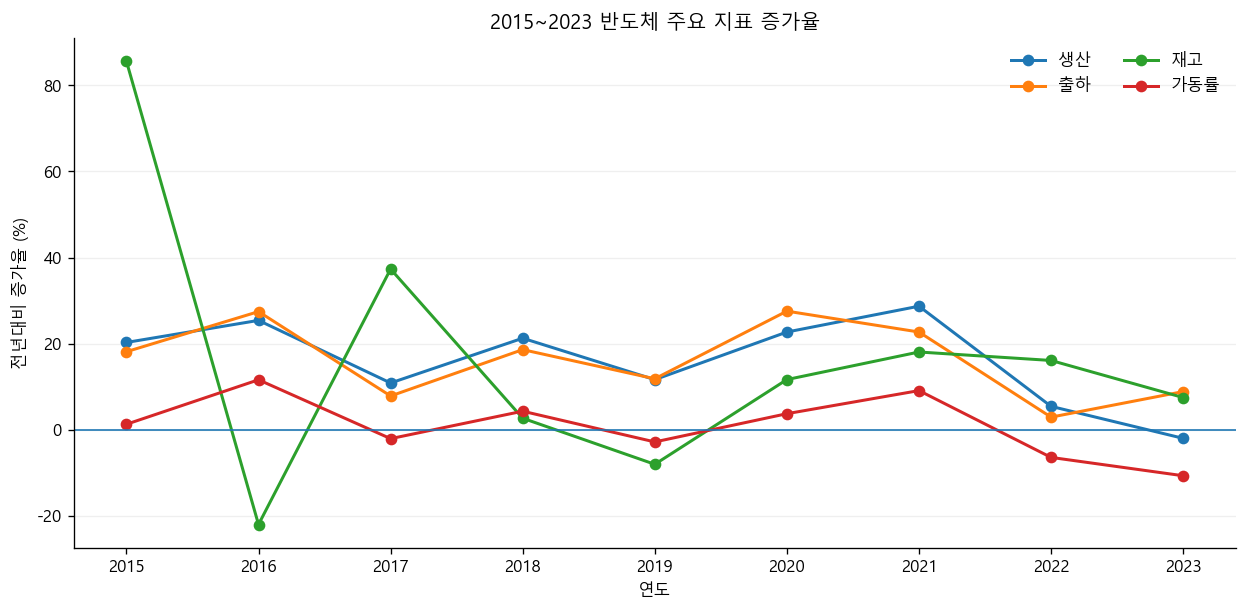

In [27]:
fig, ax = plt.subplots(figsize=(10.5, 5.2), dpi=120)

for col in [
    "생산지수_증가율",
    "출하지수_증가율",
    "재고지수_증가율",
    "가동률지수_증가율"
]:
    ax.plot(
        analysis_period["연도"],
        analysis_period[col],
        marker="o",
        linewidth=1.8,
        label=col.replace("지수_증가율", "")
    )

ax.axhline(0, linewidth=1)
ax.set_xticks(analysis_period["연도"])
ax.set_title("2015~2023 반도체 주요 지표 증가율")
ax.set_xlabel("연도")
ax.set_ylabel("전년대비 증가율 (%)")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 26. 전체기간 대비 2015~2023의 위치

In [28]:
rank_vars = [
    "생산지수_증가율",
    "출하지수_증가율",
    "재고지수_증가율",
    "가동률지수_증가율",
    "재고압력",
    "출하생산갭"
]

rank_df = df[["연도"] + rank_vars].copy()

for col in rank_vars:
    rank_df[f"{col}_백분위"] = (
        rank_df[col].rank(pct=True) * 100
    )

rank_period = rank_df[
    rank_df["연도"].between(2015, 2023)
].copy()

display(rank_period.round(1))

지표,연도,생산지수_증가율,출하지수_증가율,재고지수_증가율,가동률지수_증가율,재고압력,출하생산갭,생산지수_증가율_백분위,출하지수_증가율_백분위,재고지수_증가율_백분위,가동률지수_증가율_백분위,재고압력_백분위,출하생산갭_백분위
16,2015,20.3,18.1,85.6,1.3,67.5,-2.1,53.8,53.8,92.3,53.8,96.2,42.3
17,2016,25.4,27.4,-22.0,11.6,-49.4,2.0,69.2,69.2,11.5,92.3,3.8,84.6
18,2017,10.9,7.8,37.3,-2.1,29.5,-3.0,30.8,15.4,76.9,46.2,80.8,26.9
19,2018,21.3,18.6,2.7,4.3,-15.9,-2.6,61.5,57.7,38.5,69.2,38.5,34.6
20,2019,11.6,11.8,-8.0,-2.8,-19.9,0.2,34.6,34.6,30.8,34.6,30.8,50.0
21,2020,22.7,27.6,11.7,3.7,-15.9,4.9,65.4,73.1,46.2,65.4,42.3,92.3
22,2021,28.7,22.7,18.1,9.1,-4.6,-6.0,76.9,65.4,61.5,80.8,46.2,15.4
23,2022,5.4,2.9,16.1,-6.4,13.2,-2.5,15.4,11.5,57.7,15.4,69.2,38.5
24,2023,-2.0,8.9,7.5,-10.7,-1.4,10.9,7.7,23.1,42.3,7.7,50.0,100.0


백분위는 해당 연도의 변화가 1999~2025 전체 역사에서 어느 정도로 높거나 낮은지를 확인하기 위한 값이다.

예를 들어 재고 증가율이 90백분위 이상이면
전체 기간 가운데서도 재고 증가가 매우 컸던 해라는 의미다.

이 표를 이용하면 단순히 `증가/감소`만 보는 것보다
2015~2023년의 각 해가 과거에 비해 얼마나 특이했는지 확인할 수 있다.

# Part I. 통제변수 후보 진단

## 27. 다중공선성(VIF)

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vif_data = df[core_growth].dropna().copy()

X = sm.add_constant(vif_data)

vif_rows = []

for i, col in enumerate(X.columns):
    if col == "const":
        continue

    vif_rows.append({
        "변수": col,
        "VIF": variance_inflation_factor(X.values, i)
    })

vif_all = pd.DataFrame(vif_rows)

display(vif_all.round(3))

,변수,VIF
0,생산지수_증가율,20.212
1,출하지수_증가율,16.305
2,재고지수_증가율,2.038
3,가동률지수_증가율,2.048


현재 자료에서는 생산 증가율과 출하 증가율이 거의 같은 방향으로 움직이기 때문에
두 변수를 동시에 넣으면 VIF가 크게 올라갈 가능성이 있다.

따라서 최종 통제변수를 여러 개 사용할 경우에는:

- 생산과 출하 중 하나를 선택하고
- 재고와 가동률을 추가하는 방식

을 우선 검토할 수 있다.

In [30]:
candidate_sets = [
    ["출하지수_증가율", "재고지수_증가율", "가동률지수_증가율"],
    ["생산지수_증가율", "재고지수_증가율", "가동률지수_증가율"]
]

for cols in candidate_sets:
    X = sm.add_constant(df[cols].dropna())

    rows = []

    for i, col in enumerate(X.columns):
        if col == "const":
            continue

        rows.append({
            "변수": col,
            "VIF": variance_inflation_factor(X.values, i)
        })

    print("\n후보:", cols)
    display(pd.DataFrame(rows).round(3))


후보: ['출하지수_증가율', '재고지수_증가율', '가동률지수_증가율']


,변수,VIF
0,출하지수_증가율,2.456
1,재고지수_증가율,1.632
2,가동률지수_증가율,1.787



후보: ['생산지수_증가율', '재고지수_증가율', '가동률지수_증가율']


,변수,VIF
0,생산지수_증가율,3.044
1,재고지수_증가율,1.960
2,가동률지수_증가율,2.032


## 28. PCA로 단일 사이클 요인이 가능한지 탐색

,주성분,설명분산비율,누적설명분산
0,PC1,0.682,0.682
1,PC2,0.243,0.926
2,PC3,0.067,0.993
3,PC4,0.007,1.000


,PC1,PC2,PC3,PC4
생산지수_증가율,-0.593,-0.013,0.303,-0.746
출하지수_증가율,-0.583,0.017,0.478,0.657
재고지수_증가율,-0.380,-0.732,-0.559,0.088
가동률지수_증가율,-0.406,0.681,-0.606,0.064


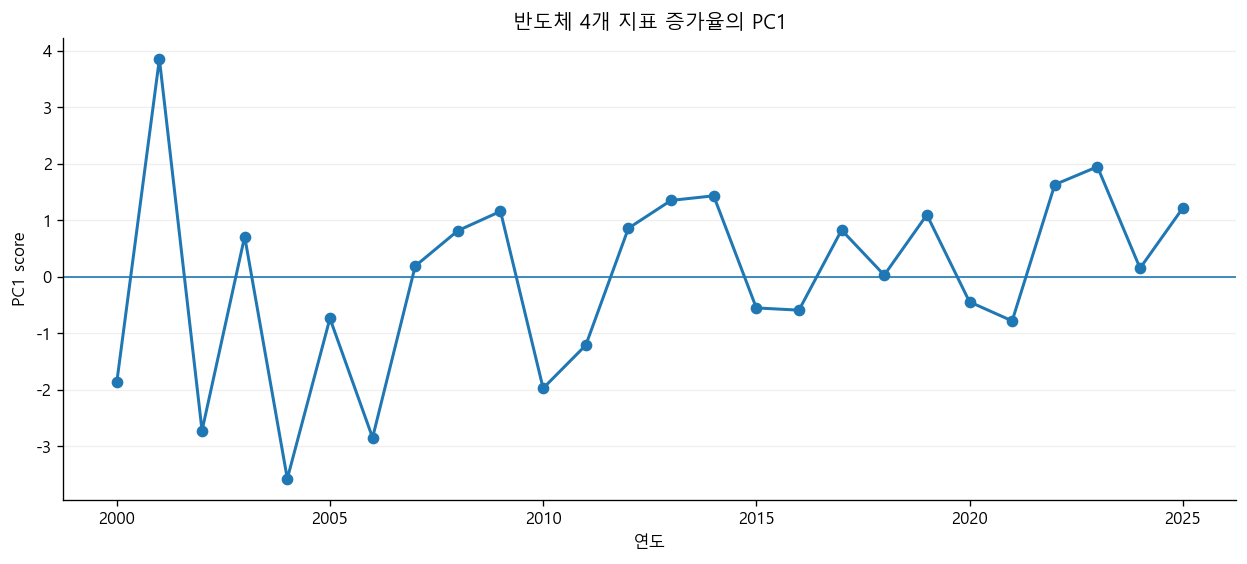

In [31]:
pca_data = df[
    ["연도"] + core_growth
].dropna().copy()

X = pca_data[core_growth].copy()

Z = (
    (X - X.mean())
    / X.std(ddof=0)
)

cov = np.cov(Z.values, rowvar=False)

eigvals, eigvecs = np.linalg.eigh(cov)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained = eigvals / eigvals.sum()

explained_table = pd.DataFrame({
    "주성분": [f"PC{i+1}" for i in range(len(explained))],
    "설명분산비율": explained,
    "누적설명분산": np.cumsum(explained)
})

display(explained_table.round(3))

loadings = pd.DataFrame(
    eigvecs,
    index=core_growth,
    columns=[f"PC{i+1}" for i in range(len(core_growth))]
)

display(loadings.round(3))

scores = Z.values @ eigvecs
pca_data["PC1"] = scores[:, 0]

fig, ax = plt.subplots(figsize=(10.5, 4.8), dpi=120)

ax.plot(
    pca_data["연도"],
    pca_data["PC1"],
    marker="o",
    linewidth=1.8
)

ax.axhline(0, linewidth=1)
ax.set_title("반도체 4개 지표 증가율의 PC1")
ax.set_xlabel("연도")
ax.set_ylabel("PC1 score")
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

현재 파일에서는 첫 번째 주성분이 전체 변동의 상당 부분을 설명한다면,
4개 지표에 공통적인 반도체 업황 요인이 존재한다고 볼 수 있다.

다만 PCA의 부호는 임의적이고 경제적 해석이 직관적이지 않을 수 있으므로,
**PC1을 바로 최종 통제변수로 결정하지 않는다.**

최종적으로는 다음을 비교하는 것이 좋다.

1. 출하 증가율 하나만 사용
2. 출하 + 재고 + 가동률 사용
3. PCA로 만든 하나의 반도체 사이클 요인 사용

그리고 본 회귀의 계수·표준오차·적합도가 얼마나 민감한지 비교한다.

# Part J. 현재 단계 결론

## 29. EDA에서 확인된 핵심

### 1) 원자료 자체

- 1999~2025년의 27개 연도가 존재한다.
- 생산·출하·재고·가동률 4개 지표를 모두 사용할 수 있다.
- 원자료 수준의 장기 추세가 강하기 때문에 통제변수로는 **원지수 자체보다 증가율 또는 변화량**이 더 자연스럽다.

### 2) 생산과 출하

생산과 출하는 원지수뿐 아니라 증가율에서도 매우 비슷하게 움직인다.
따라서 두 변수를 동시에 통제하면 다중공선성이 커질 수 있다.

### 3) 재고

재고 증가율은 생산·출하보다 변동성이 크다.
반도체 업황의 재고조정 국면을 포착하는 별도 정보가 있어 보인다.

### 4) 가동률

가동률 변화는 생산·출하와 관련되지만 완전히 같은 정보는 아니다.
설비 활용 정도라는 점에서 업황 통제로 추가적인 의미가 있을 수 있다.

### 5) 2015~2023

이 기간 안에서도 재고부담과 생산·출하·가동률의 방향이 계속 바뀐다.
특히 연도별 평균자료만 사용하면 한 해 안의 사이클 전환이 합쳐질 수 있으므로
사이클 전환시점을 지나치게 세밀하게 해석하지 않는다.

### 6) 통제변수 후보

현 단계에서는 다음 세 가지 안을 남겨두는 것이 적절하다.

- **안 A:** 출하 증가율 하나
- **안 B:** 출하 증가율 + 재고 증가율 + 가동률 증가율
- **안 C:** 4개 증가율을 표준화한 PCA의 PC1

이후 재무·원자재 병합패널에 붙여 실제 회귀에서 세 안을 비교한 뒤 결정한다.